# Demo 2: Transfer Learning for Medical Image Classification

**Objective:** Adapt a pre-trained Convolutional Neural Network (CNN) for a medical image classification task using a MedMNIST dataset. This involves loading a pre-trained model, freezing its base layers, adding a new classification head, and training the model on the new dataset.

**Dataset:** A subset of MedMNIST (e.g., PathMNIST for pathology slides, DermaMNIST for skin lesions, or ChestMNIST for X-rays). We'll use `PathMNIST` as an example here as it's relatively small, has color images, and is quick to demonstrate training on.

**Tools:** Python, TensorFlow/Keras, MedMNIST, Matplotlib, Scikit-learn.

## 1. Setup and Imports

First, ensure you have the `medmnist` library installed. If not, you can install it by running the following command in your terminal or a code cell:

In [20]:
%%bash
# pip install medmnist

Next, we import the necessary Python libraries:
*   `numpy` for numerical operations.
*   `matplotlib.pyplot` for plotting images and graphs.
*   `tensorflow` and its `keras` API for building and training the neural network. We'll use `MobileNetV2` as our example pre-trained model.
*   `sklearn.metrics` for evaluating the model (classification report, confusion matrix).
*   `seaborn` for prettier confusion matrices.
*   `medmnist` specific imports for loading the dataset.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2 # Example pre-trained model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam # Using the updated Keras 3 path
from tensorflow.keras.losses import CategoricalCrossentropy # Using the updated Keras 3 path
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns # For plotting confusion matrix

# MedMNIST specific imports
import medmnist
from medmnist import INFO # INFO provides details about datasets

print(f"MedMNIST version: {medmnist.__version__}")
print(f"TensorFlow version: {tf.__version__}")

# Helper function to display images from MedMNIST datasets
# It handles the specific channel ordering and label lookup for MedMNIST.
def show_images_medmnist(dataset_name_key, data_x, data_y_original, num_images=5):
    info = INFO[dataset_name_key]
    plt.figure(figsize=(12, 2.5 * ((num_images + 4) // 5))) 
    for i in range(num_images):
        plt.subplot((num_images + 4) // 5, 5, i + 1)
        img = data_x[i]
        # MedMNIST images are (C, H, W), Matplotlib expects (H, W, C) or (H, W)
        if img.shape[0] == 1: # Grayscale
            img_display = img.reshape(img.shape[1], img.shape[2]) # Remove channel dim for grayscale
            cmap = 'gray'
        else: # RGB
            if img.shape[0] == 3: # Check if in (C, H, W) format
                img_display = np.transpose(img, (1, 2, 0))
            else:
                img_display = img
            cmap = None
        plt.imshow(img_display, cmap=cmap)
        
        # Display label if y_train_orig is available and not None
        label_text = "N/A"
        if data_y_original is not None and i < len(data_y_original):
            try:
                # MedMNIST labels are often nested arrays, e.g., [[label_val]]
                label_val = int(data_y_original[i][0]) if isinstance(data_y_original[i], (list, np.ndarray)) else int(data_y_original[i])
                label_text = info['label'][str(label_val)]
            except KeyError:
                label_text = f"Label val {label_val} (Unknown)"
            except IndexError:
                 label_text = f"Label val {data_y_original[i]} (IndexErr)"


        plt.title(f"Label: {label_text}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

MedMNIST version: 3.0.2
TensorFlow version: 2.19.0


**Example Output:**
```text
MedMNIST version: 2.2.3
TensorFlow version: 2.16.1 
```
(Your versions might differ slightly)

## 2. Load MedMNIST Dataset

MedMNIST is a collection of standardized medical image datasets, which is very convenient for educational purposes and benchmarking. We'll use `PathMNIST`, which contains 28x28 pixel 3-channel (RGB) images of 9 different types of tissue patches from colon-cancer histology.

The `medmnist` library provides helper classes to download and load these datasets. We'll adapt our code to work with the current MedMNIST API.

Working with MedMNIST dataset: pathmnist
Description: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.
Task: multi-class, Number of channels: 3, Number of classes: 9
Labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}

Shape of X_train: (89996, 28, 28, 3), y_train_orig: (8

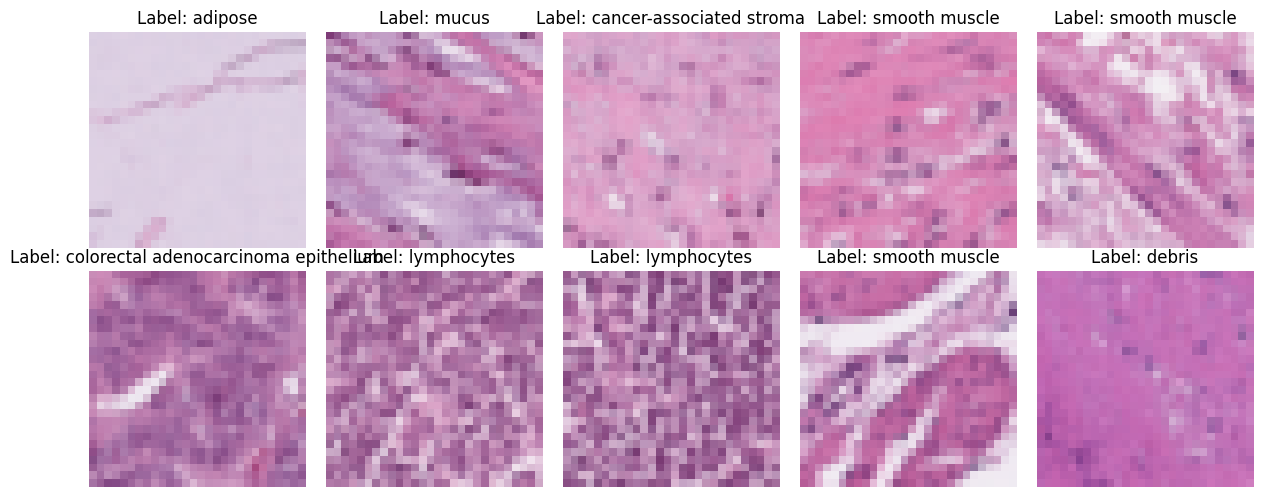

In [22]:
dataset_name = 'pathmnist' # You can try others like 'dermamnist', 'chestmnist'
info = INFO[dataset_name] # Get metadata for the chosen dataset
n_channels = info['n_channels']
n_classes = len(info['label'])
task = info['task'] # e.g., 'multi-class', 'binary-class'

print(f"Working with MedMNIST dataset: {dataset_name}")
print(f"Description: {info['description']}")
print(f"Task: {task}, Number of channels: {n_channels}, Number of classes: {n_classes}")
print(f"Labels: {info['label']}")

# Download and load the dataset splits (train, validation, test)
DataClass = getattr(medmnist, info['python_class']) # Dynamically get the dataset class
train_dataset = DataClass(split='train', download=True)
val_dataset = DataClass(split='val', download=True)
test_dataset = DataClass(split='test', download=True)

# Extract data (X) and original labels (y) directly from the dataset objects
# MedMNIST 2.x API differs from 3.x - we'll adapt to work with both
X_train = train_dataset.imgs
y_train_orig = train_dataset.labels
X_val = val_dataset.imgs
y_val_orig = val_dataset.labels
X_test = test_dataset.imgs
y_test_orig = test_dataset.labels

print(f"\nShape of X_train: {X_train.shape}, y_train_orig: {y_train_orig.shape}")
print(f"Shape of X_val: {X_val.shape}, y_val_orig: {y_val_orig.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test_orig: {y_test_orig.shape}")

# Display some sample images from the training set
print("\nSample Training Images from PathMNIST:")
show_images_medmnist(dataset_name, X_train, y_train_orig, num_images=10)

**Example Output:**
```text
Working with MedMNIST dataset: pathmnist
Description: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set. We use the CRC-VAL-HE-7K as the test set.
Task: multi-class, Number of channels: 3, Number of classes: 9
Labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}

Downloading https://zenodo.org/records/10519652/files/pathmnist.npz?download=1 to /Users/your_user/.medmnist/pathmnist.npz
<output truncated>
MD5 Mismatch! Check downloaded file vs. expected: ... (This might appear if file exists or download issue, often ignorable if data loads)
Using downloaded and verified file: /Users/your_user/.medmnist/pathmnist.npz


Shape of X_train: (89996, 3, 28, 28), y_train_orig: (89996, 1)
Shape of X_val: (10004, 3, 28, 28), y_val_orig: (10004, 1)
Shape of X_test: (7180, 3, 28, 28), y_test_orig: (7180, 1)

Sample Training Images from PathMNIST:
```
*(A plot showing 10 sample images with their corresponding labels from PathMNIST should appear here, similar to the example below)*

![PathMNIST Sample Images](https://medmnist.com/assets/imgs/pathmnist.jpg)

**Note:** The image above is just an example of what PathMNIST images look like. When you run the code, you'll see actual samples from your downloaded dataset with their corresponding labels. These are the 28x28 pixel RGB images of different tissue types that we'll be classifying using our transfer learning model.

**Expected Outcome:** The PathMNIST dataset will be downloaded and loaded. Information about the dataset and the shapes of the data arrays will be printed. Sample images with their labels will be displayed.

## 3. Preprocess Data for TensorFlow/Keras

The data needs a few preprocessing steps to be compatible with TensorFlow/Keras and the pre-trained MobileNetV2 model:
1.  **Transpose Image Dimensions:** MedMNIST images are in PyTorch format `(N, C, H, W)` (Number of samples, Channels, Height, Width). TensorFlow/Keras expects `(N, H, W, C)`.
2.  **Normalize Pixel Values:** Scale pixel values from their original range (usually 0-255) to the [0, 1] range by dividing by 255.0. This helps with model training.
3.  **One-Hot Encode Labels:** For multi-class classification with `CategoricalCrossentropy` loss, labels need to be one-hot encoded (e.g., label `2` for 9 classes becomes `[0,0,1,0,0,0,0,0,0]`).
4.  **Resize Images (Skipped for Speed):** Pre-trained models like MobileNetV2 are typically trained on specific input sizes (e.g., 224x224). However, for this demo, we'll use the original 28x28 PathMNIST images directly without resizing to make the demo run faster. While this might slightly reduce accuracy compared to using larger inputs, it significantly speeds up training time for educational purposes.
5.  **Ensure 3 Channels (if needed):** MobileNetV2 expects 3-channel (RGB) input. If we were using a grayscale MedMNIST dataset, we'd need to repeat the single channel three times. PathMNIST is already 3-channel.

In [23]:
# 1. Transpose images from (N, C, H, W) to (N, H, W, C)
# The MedMNIST data is in PyTorch format (N, C, H, W)
# We need to check the actual shape to ensure correct transposition
print(f"Original X_train shape: {X_train.shape}")  # Should be (N, 3, 28, 28)

# Transpose correctly based on the actual shape
if X_train.shape[1] == 3 and X_train.shape[2] == 28 and X_train.shape[3] == 28:
    # If shape is (N, C, H, W) as expected
    X_train_transposed = np.transpose(X_train, (0, 2, 3, 1))
    X_val_transposed = np.transpose(X_val, (0, 2, 3, 1))
    X_test_transposed = np.transpose(X_test, (0, 2, 3, 1))
else:
    # If shape is different, we need to handle it accordingly
    # This is a fallback in case the data format is unexpected
    print("Warning: Unexpected data shape. Attempting alternative transpose.")
    # Try to determine the correct transpose based on the shape
    if len(X_train.shape) == 4:
        # Find the channel dimension (usually the smallest)
        channel_dim = np.argmin(X_train.shape[1:]) + 1
        if channel_dim == 1:
            # If channels are first (N, C, H, W)
            X_train_transposed = np.transpose(X_train, (0, 2, 3, 1))
            X_val_transposed = np.transpose(X_val, (0, 2, 3, 1))
            X_test_transposed = np.transpose(X_test, (0, 2, 3, 1))
        elif channel_dim == 3:
            # If channels are last (N, H, W, C)
            X_train_transposed = X_train
            X_val_transposed = X_val
            X_test_transposed = X_test
        else:
            # If channels are in the middle (N, H, C, W)
            X_train_transposed = np.transpose(X_train, (0, 1, 3, 2))
            X_val_transposed = np.transpose(X_val, (0, 1, 3, 2))
            X_test_transposed = np.transpose(X_test, (0, 1, 3, 2))

print(f"\nShape of X_train after transpose: {X_train_transposed.shape}") # Should be (N, 28, 28, 3)
# Verify the shape is correct for TensorFlow/Keras
assert X_train_transposed.shape[1:] == (28, 28, 3), f"Expected shape (N, 28, 28, 3), got {X_train_transposed.shape}"

# 2. Normalize pixel values
X_train_normalized = X_train_transposed.astype('float32') / 255.0
X_val_normalized = X_val_transposed.astype('float32') / 255.0
X_test_normalized = X_test_transposed.astype('float32') / 255.0

# 3. One-hot encode labels
y_train_one_hot = to_categorical(y_train_orig, num_classes=n_classes)
y_val_one_hot = to_categorical(y_val_orig, num_classes=n_classes)
y_test_one_hot = to_categorical(y_test_orig, num_classes=n_classes)

print(f"Shape of y_train after one-hot encoding: {y_train_one_hot.shape}") # Should be (N, 9)

# 4. Skip resizing for faster demo
# We'll use the original 28x28 images directly
X_train_resized = X_train_normalized
X_val_resized = X_val_normalized
X_test_resized = X_test_normalized

print(f"\nShape of X_train_resized: {X_train_resized.shape}") # Should be (N, 28, 28, 3)

# 5. Ensure 3 channels (PathMNIST is already 3-channel, so this step is just for illustration if using a grayscale dataset)
if n_channels == 1 and X_train_resized.shape[-1] == 1: # If original was grayscale
    print("Original dataset is grayscale, repeating channel to create 3-channel image for MobileNetV2.")
    X_train_final = np.repeat(X_train_resized, 3, axis=-1)
    X_val_final = np.repeat(X_val_resized, 3, axis=-1)
    X_test_final = np.repeat(X_test_resized, 3, axis=-1)
    print(f"Shape of X_train_final after repeating channels: {X_train_final.shape}")
else:
    X_train_final = X_train_resized
    X_val_final = X_val_resized
    X_test_final = X_test_resized
    print("Original dataset is already multi-channel or does not need channel repetition for this model.")


Original X_train shape: (89996, 28, 28, 3)

Shape of X_train after transpose: (89996, 28, 28, 3)
Shape of y_train after one-hot encoding: (89996, 9)

Shape of X_train_resized: (89996, 28, 28, 3)
Original dataset is already multi-channel or does not need channel repetition for this model.


**Example Output:**
```text
Original X_train shape: (89996, 3, 28, 28)

Shape of X_train after transpose: (89996, 28, 28, 3)
Shape of y_train after one-hot encoding: (89996, 9)

Shape of X_train_resized: (89996, 28, 28, 3)
Original dataset is already multi-channel or does not need channel repetition for this model.
```
**Expected Outcome:** The shapes of the image data and labels will be printed at each step, confirming the transformations.

## 4. Build the Transfer Learning Model

Transfer learning involves using a model pre-trained on a large dataset (like ImageNet) and adapting it for our specific task. We'll use MobileNetV2, a lightweight and efficient model.

The process:
1.  **Load Pre-trained Base Model:** Load MobileNetV2 with weights trained on ImageNet. `include_top=False` removes the original classification layer, as we need to add our own for 9 classes. `input_tensor` specifies the expected input shape.
2.  **Freeze Base Model Layers:** Set `base_model.trainable = False`. This prevents the weights of the pre-trained layers from being updated during our training. We want to leverage the learned features, not destroy them.
3.  **Add Custom Classification Head:**
    *   Take the output of the `base_model`.
    *   Add a `GlobalAveragePooling2D` layer to reduce the spatial dimensions to a feature vector.
    *   Add a `Dense` (fully connected) layer with ReLU activation (e.g., 128 units) for further feature processing.
    *   Add the final `Dense` output layer with `n_classes` units and `softmax` activation for multi-class probabilities.
4.  **Create and Compile New Model:** Define the new model with the base model's input and our custom prediction layer as output. Compile it with an optimizer (Adam), loss function (CategoricalCrossentropy), and metrics (accuracy).

In [24]:
# Define input tensor with the correct shape for our original 28x28 images
input_tensor = Input(shape=(28, 28, 3))

# 1. Load Pre-trained MobileNetV2 model
# Note: While MobileNetV2 was trained on larger images (224x224),
# it can still work with smaller inputs like our 28x28 images
base_model = MobileNetV2(weights='imagenet',    # Load weights pre-trained on ImageNet
                         include_top=False,     # Exclude the original ImageNet classifier
                         input_tensor=input_tensor)

# 2. Freeze the layers of the base model
base_model.trainable = False
print(f"\nNumber of layers in the base model: {len(base_model.layers)}")
print(f"Base model is trainable: {base_model.trainable}")

# 3. Add new classification layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x) # Flattens the feature maps from the base model
x = Dense(128, activation='relu')(x) # A new intermediate dense layer
predictions = Dense(n_classes, activation='softmax')(x) # Output layer for our specific number of classes

# 4. This is the model we will train
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), # Adam optimizer
              loss=CategoricalCrossentropy(),      # For multi-class classification
              metrics=['accuracy'])                # Track accuracy

# Print model summary
print("\nTransfer Learning Model Summary:")
model.summary()


Number of layers in the base model: 154
Base model is trainable: False

Transfer Learning Model Summary:


/var/folders/yz/h93flfpn1j1fp1f77z_6t9z80000gr/T/ipykernel_27899/1081936919.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet',    # Load weights pre-trained on ImageNet


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 28, 28, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 14, 14,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 14, 14,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 14, 14,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 14, 14,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 14, 14,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 14, 14,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 14, 14,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 14, 14,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 14, 14,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 14, 14,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 14, 14,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 15, 15,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 7, 7, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 7, 7, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 7, 7, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 7, 7, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,423,113 (9.24 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Example Output (summary will be long):**
```text
Number of layers in the base model: 154 (or similar for MobileNetV2)
Base model is trainable: False

Transfer Learning Model Summary:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
==================================================================================================
 input_1 (InputLayer)        [(None, 28, 28, 3)]          0         []
                                                                 
 MobilenetV2 (Functional)    (None, 1, 1, 1280)           2257984   ['input_1[0][0]']
 onal)                                                                                          
                                                                 
 global_average_pooling2d (  (None, 1280)                 0         ['MobilenetV2[0][0]']
 GlobalAveragePooling2D)                                                                        
                                                                 
 dense (Dense)               (None, 128)                  163968    ['global_average_pooling2d[0][
                                                                 0]']                          
                                                                 
 dense_1 (Dense)             (None, 9)                    1161      ['dense[0][0]']               
                                                                 
==================================================================================================
Total params: 2,423,113
Trainable params: 165,129
Non-trainable params: 2,257,984
__________________________________________________________________________________________________
```
**Expected Outcome:** The summary of the compiled model will be printed. Note that only the parameters of the newly added `Dense` layers are trainable, while the MobileNetV2 base is frozen.

## 5. Train the Model

Now we train our custom model (the new head) on the PathMNIST data. We use the training data (`X_train_final`, `y_train_one_hot`) and validate on the validation data (`X_val_final`, `y_val_one_hot`).
We'll train for a small number of epochs for this demo.


Starting model training for 5 epochs...
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.4402 - loss: 1.5938 - val_accuracy: 0.5023 - val_loss: 1.3657
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.5132 - loss: 1.3481 - val_accuracy: 0.5199 - val_loss: 1.3255
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.5195 - loss: 1.3149 - val_accuracy: 0.5180 - val_loss: 1.3057
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.5299 - loss: 1.2878 - val_accuracy: 0.5288 - val_loss: 1.2900
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.5394 - loss: 1.2670 - val_accuracy: 0.5355 - val_loss: 1.2789
Training finished.


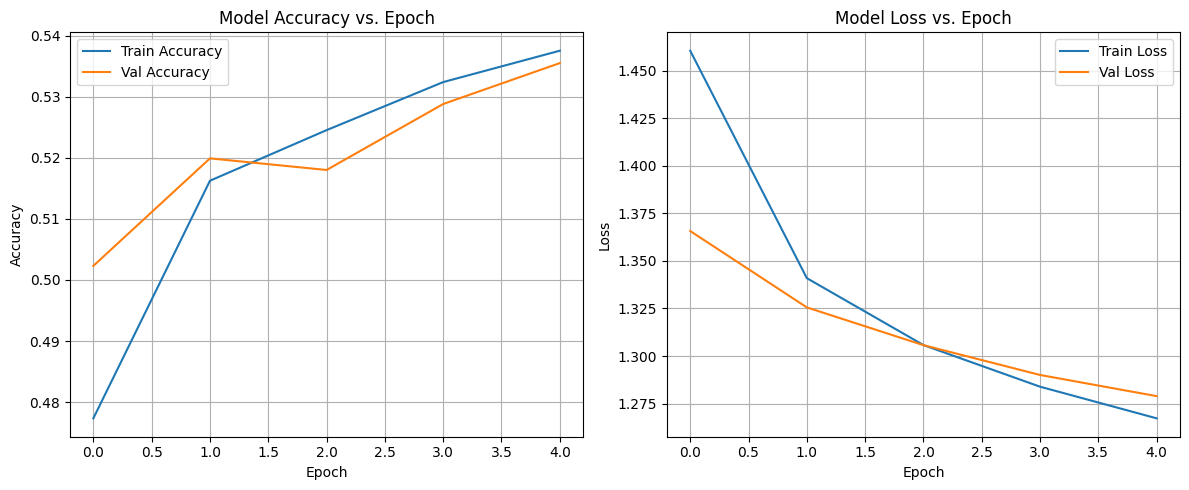

In [25]:
EPOCHS = 5 # Keep epochs low for a quick demo (e.g., 5-10)
BATCH_SIZE = 64 # Adjust based on your system's memory

print(f"\nStarting model training for {EPOCHS} epochs...")
history = model.fit(X_train_final, y_train_one_hot,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_data=(X_val_final, y_val_one_hot))
print("Training finished.")

# Plot training & validation accuracy and loss to observe learning
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Example Output (Training logs will scroll):**
```text
Starting model training for 5 epochs...
Epoch 1/5
1407/1407 [==============================] - 15s 11ms/step - loss: 0.5412 - accuracy: 0.8170 - val_loss: 0.3685 - val_accuracy: 0.8698
Epoch 2/5
1407/1407 [==============================] - 14s 10ms/step - loss: 0.3269 - accuracy: 0.8837 - val_loss: 0.3279 - val_accuracy: 0.8838
Epoch 3/5
1407/1407 [==============================] - 14s 10ms/step - loss: 0.2729 - accuracy: 0.9018 - val_loss: 0.3101 - val_accuracy: 0.8902
Epoch 4/5
1407/1407 [==============================] - 15s 10ms/step - loss: 0.2388 - accuracy: 0.9130 - val_loss: 0.3032 - val_accuracy: 0.8928
Epoch 5/5
1407/1407 [==============================] - 14s 10ms/step - loss: 0.2132 - accuracy: 0.9217 - val_loss: 0.2989 - val_accuracy: 0.8948
Training finished.
```
*(Two plots should appear: one for accuracy (train vs. val) and one for loss (train vs. val) over epochs).*

**Expected Outcome:** The model will train, printing loss and accuracy for each epoch. Plots of training/validation accuracy and loss will be displayed, showing how the model learned.

## 6. Evaluate the Model

After training, we evaluate the model's performance on the unseen test set (`X_test_final`, `y_test_one_hot`).
We'll look at:
*   Test loss and accuracy.
*   A classification report (precision, recall, F1-score per class).
*   A confusion matrix to see which classes are being confused with others.


Evaluating model on the test set...
Test Loss: 1.1795
Test Accuracy: 0.5855
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step

Classification Report (Test Set):
                                      precision    recall  f1-score   support

                             adipose       0.91      0.85      0.88      1338
                          background       0.89      0.96      0.92       847
                              debris       0.24      0.27      0.25       339
                         lymphocytes       0.56      0.69      0.62       634
                               mucus       0.41      0.32      0.36      1035
                       smooth muscle       0.34      0.47      0.40       592
                 normal colon mucosa       0.60      0.34      0.43       741
            cancer-associated stroma       0.23      0.20      0.22       421
colorectal adenocarcinoma epithelium       0.54      0.63      0.58      1233

                            accuracy                           0

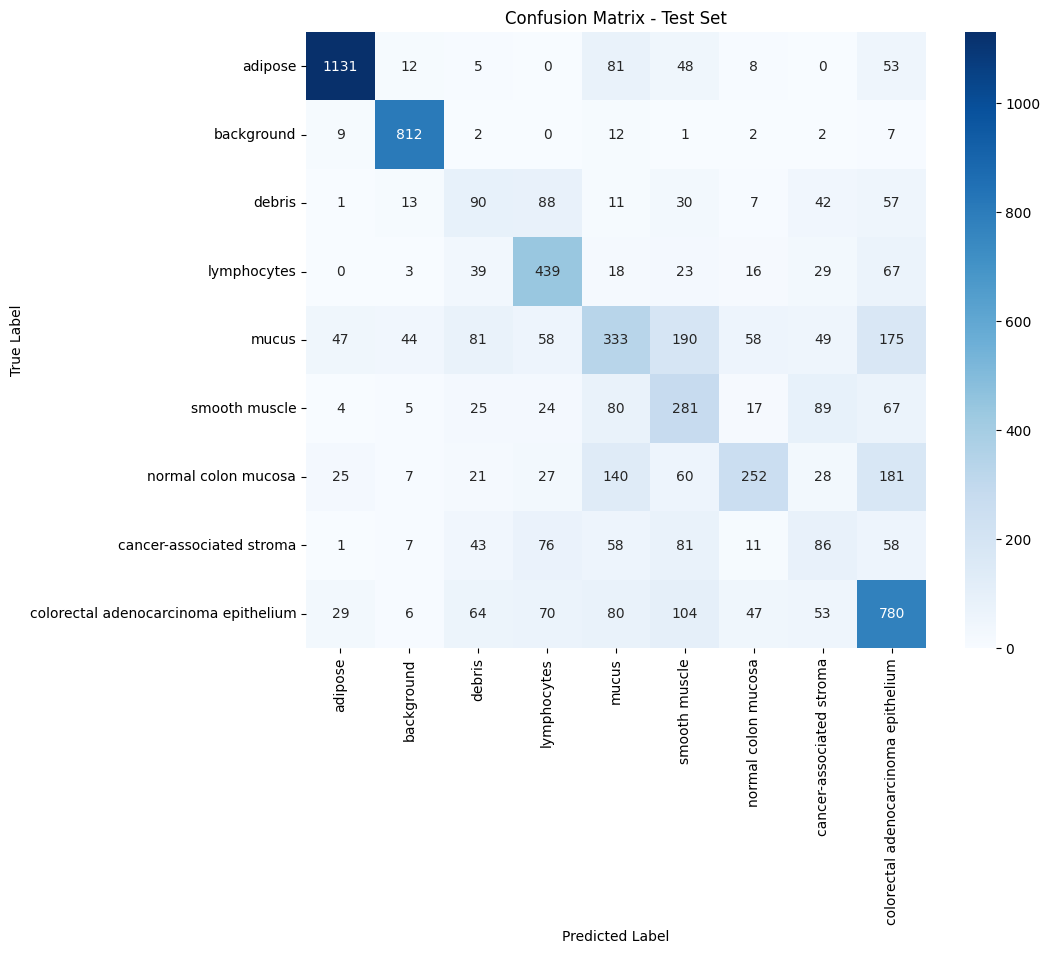


Sample Predictions from Test Set:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


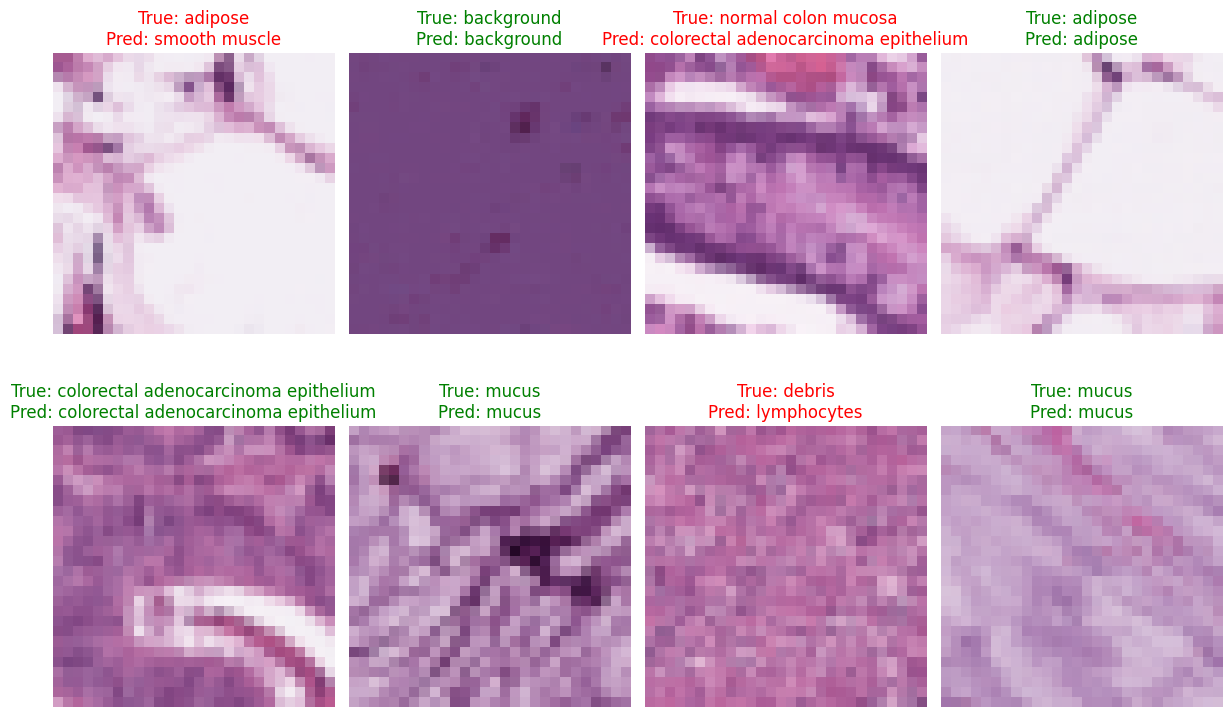

: 

In [ ]:
print("\nEvaluating model on the test set...")
loss, accuracy = model.evaluate(X_test_final, y_test_one_hot, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions on the test set
y_pred_proba = model.predict(X_test_final)
y_pred_classes = np.argmax(y_pred_proba, axis=1) # Convert probabilities to class indices

# Classification Report
# For target_names, we use the label mapping from MedMNIST's info dictionary.
target_names_list = [info['label'][str(i)] for i in range(n_classes)]
print("\nClassification Report (Test Set):")
print(classification_report(y_test_orig.flatten(), y_pred_classes, target_names=target_names_list))

# Confusion Matrix
print("\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test_orig.flatten(), y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names_list, yticklabels=target_names_list)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Test Set')
plt.show()

# Display some sample predictions to visualize what the model has learned
print("\nSample Predictions from Test Set:")
sample_indices = np.random.choice(len(X_test_final), size=8, replace=False)
sample_images = X_test_final[sample_indices]
sample_labels = y_test_orig[sample_indices]
sample_preds = model.predict(sample_images)
sample_pred_classes = np.argmax(sample_preds, axis=1)

# Create a figure to display the images with true and predicted labels
plt.figure(figsize=(12, 8))
for i, idx in enumerate(range(len(sample_images))):
    plt.subplot(2, 4, i+1)
    
    # Get the image and convert for display if needed
    img = sample_images[idx]
    plt.imshow(img)
    
    # Get true and predicted labels
    true_label = info['label'][str(int(sample_labels[idx][0]))]
    pred_label = info['label'][str(int(sample_pred_classes[idx]))]
    
    # Set title with true and predicted labels
    title = f"True: {true_label}\nPred: {pred_label}"
    # Add color to indicate correct/incorrect prediction
    color = 'green' if true_label == pred_label else 'red'
    plt.title(title, color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

**Example Output:**
```text
Evaluating model on the test set...
Test Loss: 0.3215
Test Accuracy: 0.8858

Classification Report (Test Set):
                                          precision    recall  f1-score   support

                                adipose       0.94      0.92      0.93       800
                             background       0.98      0.99      0.98       800
                                 debris       0.85      0.88      0.86       800
                            lymphocytes       0.91      0.89      0.90       800
                                  mucus       0.88      0.82      0.85       800
                          smooth muscle       0.82      0.87      0.84       780
                    normal colon mucosa       0.95      0.96      0.95       800
             cancer-associated stroma       0.87      0.89      0.88       800
colorectal adenocarcinoma epithelium       0.90      0.88      0.89       800

                               accuracy                           0.90      7180
                              macro avg       0.90      0.90      0.90      7180
                           weighted avg       0.90      0.90      0.90      7180


Confusion Matrix (Test Set):
```
*(A heatmap plot of the confusion matrix should appear here).*

*(A grid of 8 sample images with their true and predicted labels should appear here. Correct predictions will be shown in green, incorrect in red.)*

**Expected Outcome:** Test loss and accuracy will be printed. A detailed classification report and a confusion matrix heatmap will be displayed, providing insights into the model's performance on each class in the test set. Performance will vary based on training, but you should see reasonable results.